In [1]:
print(5+5)

10


In [2]:
import sys
sys.path.append('../../datasets')
#from spark_utils import *
import getpass
import pathlib
import os
import io
from tqdm import tqdm
from optuna.samplers import TPESampler
#import datadicts as dd
import pathlib
import sys
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
import catboost as cb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn import metrics
import optuna
import shap
#from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_curve
import warnings
warnings.filterwarnings('ignore')

import pickle

from sklearn.preprocessing import LabelEncoder

/opt/user-venvs/python3.8/lib64/python3.8/site-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/opt/user-venvs/python3.8/lib64/python3.8/site-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimization_order(al

In [3]:
import logging
import pandas as pd
from tqdm import tqdm

logging.basicConfig(level=logging.INFO, format='[%(asctime)s %(levelname)s - %(message)s]')

def normalize_column_names(data):
    logging.info("Приведение колонок к нижнему регистру")
    rename_map = {col: col.lower() for col in data.columns if col != col.lower()}
    return data.rename(columns=rename_map)

def remove_bad_columns(data):
    logging.info("Удаление плохих признаков")
    bad_columns = []
    
    # Исключаем epk_id из удаляемых колонок
    id_columns = list(filter(lambda x: x[-3:] in ["_id", "_dk"], data.columns))
    id_columns = [col for col in id_columns if col not in ["epk_id"]]  # сохраняем epk_id
    bad_columns += id_columns
    
    bad_columns += list(filter(lambda x: x[:4] in ["act"], data.columns))
    bad_columns += [col for col in data.columns if '_oi_' in col]
    
    bad_columns += [
          "ctl_loading"
        , "row_upd_dttm"
        , "prl_tax_payer_inn"
        , "prl_agrmnt_nbr"
        , "dep_payroll_bitmask_l12m_cd"
        , "dep_social_bitmask_l12m_cd"
        , "crd_lst_agrmnt_vsp_cd"
        , "crd_lst_agrmnt_osb_cd"
        , "prd_lst_prod_osb_cd"
        , 'birth_dt'
        , 'sd_age_mnth_comp_nv'            
        , 'sd_age_yrs_comp_nv'
        , 'data_type'
        , 'type'
        , 'sd_age_yrs_comp_nv'
        , 'crd_lst_agrmnt_tb_cd'
        , 'prl_tbholding_id'
        , 'dep_lst_payroll_agrmnt_id'
        , 'dep_acct_1st_division_dk'
        , 'dep_acct_lst_division_dk'
        , 'dep_acct_max_bal_division_dk'
        , 'prd_1st_prod_division_dk'
        , 'prd_lst_prod_division_dk'
        , 'seg_main_card_dwh_id'
        , 'tp_lst_division_dk'
        , 'crd_cc_lst_plastic_type_id'
        , 'crd_dc_lst_plastic_type_id'
        , 'prd_lst_prod_vsp_cd'
        , 'seg_crd_pos_cat_group'
        , 'seg_crm_segment_cd'
        , 'seg_client_cx_segment_cd'
        , 'seg_client_cx_criteria'
        , 'prl_tax_payer_inn'
        , 'prd_1st_prod_division_dk'
        , 'tp_lst_tb_cd'
        , 'tp_lst_kind_cd'
        , 'sd_dead_nflag'
    ]
    
    # Исключаем report_dt из удаляемых колонок
    if "report_dt" in bad_columns:
        bad_columns.remove("report_dt")
    
    bad_columns = list(set(bad_columns))
    bad_columns = [col for col in bad_columns if col in data.columns]
    
    logging.info(f"Удалено {len(bad_columns)} колонок: {bad_columns}")
    return data.drop(columns=bad_columns, errors="coerce")

def process_date_columns(data, report_col="report_dt"):
    logging.info("Преобразование datetime колонок в 'дни до report_dt'")
    
    if report_col not in data.columns:
        logging.warning(f"Колонка {report_col} отсутствует в данных")
        return data
    
    # Преобразуем report_dt в datetime
    data[report_col] = pd.to_datetime(data[report_col].astype(str), errors="coerce")
    
    # Находим все датовые колонки, исключая report_dt
    date_cols = [col for col in data.columns if "_dt" in col and col != report_col]
    
    # Также можно добавить другие колонки с датами по названию
    date_keywords = ['_date', '_dttm', '_time']
    for keyword in date_keywords:
        date_cols += [col for col in data.columns if keyword in col and col not in date_cols and col != report_col]
    
    date_cols = list(set(date_cols))
    
    logging.info(f"Найдено {len(date_cols)} датовых колонок для обработки")
    
    for col in tqdm(date_cols, desc="Обработка дат"):
        data[col] = pd.to_datetime(data[col].astype(str), errors="coerce")
        # Преобразуем в количество дней до report_dt
        data[col] = (data[report_col] - data[col]).dt.days
    
    # НЕ удаляем report_dt - просто возвращаем данные с этой колонкой
    return data

def fill_missing_values(data):
    # Теперь исключаем epk_id и report_dt из заполнения
    EXCLUDED_COLS = ["report_dt", "epk_id"]
    
    logging.info("Заполнение пропусков")
    fill_config = {
        "flg":               {"fill": -1,   "type": "int32"},
        "_qty":              {"fill": -999999},
        "_pct":              {"fill": -999999},
        "_days":             {"fill": -999999},
        "_num":              {"fill": -999999},
        "_amt":              {"fill": -999999},
        "_prc":              {"fill": -999999},
        "_rate":             {"fill": -999999,   "type": "float64"},
        "_frac":             {"fill": -999999,   "type": "float64"},
        "_nflag":            {"fill": -999999,   "type": "float64"},
        "_dt":               {"fill": -999999,   "type": "float64"},
        "float64":           {"fill": -999999},
        "int32":             {"fill": -999999},
        "object":            {"fill": 'UNKNOWN'}
    }
   
    for col in tqdm(data.columns, desc="Заполнение пропусков"):
        if col in EXCLUDED_COLS:
            continue
        
        col_handled = False
       
        for pattern, rule in fill_config.items():
            if pattern in col:
                fill_val = rule["fill"]
                dtype = rule.get("type", None)
                data[col] = data[col].fillna(fill_val)
                if dtype:
                    data[col] = data[col].astype(dtype)
                col_handled = True
                break
               
        if not col_handled:
            col_type = str(data[col].dtype)
            if col_type in fill_config:
                fill_val = fill_config[col_type]["fill"]
                dtype = fill_config[col_type].get("type", None)
                data[col] = data[col].fillna(fill_val)
                if dtype:
                    data[col] = data[col].astype(dtype)
                   
    return data

def preprocess(data):
    logging.info("Старт предобработки")
    data = normalize_column_names(data)
    data = remove_bad_columns(data)
    data = process_date_columns(data, report_col="report_dt")
    data = fill_missing_values(data)
    cat_features = data.select_dtypes(include="object").columns.tolist()
    
    # Проверяем, что нужные колонки сохранились
    if "epk_id" not in data.columns:
        logging.warning("Колонка epk_id не найдена после предобработки!")
    if "report_dt" not in data.columns:
        logging.warning("Колонка report_dt не найдена после предобработки!")
    
    logging.info(f"Предобработка завершена. Число признаков: {data.shape[1]}")
    logging.info(f"Колонки сохранены: epk_id={'epk_id' in data.columns}, report_dt={'report_dt' in data.columns}")
    
    return data, cat_features

def prepare_dataset(train_df):
    logging.info("=== Запуск подготовки датасетов ===")
    train_df, cat_features = preprocess(train_df)
    logging.info(f"=== Подготовка завершена. Число признаков: {train_df.shape[1]} ===")
    return train_df, cat_features


In [4]:
def remove_corelated_features(df, threshold = 0.97, method = 'pearson'):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    non_numeric_cols = df.columns.difference(numeric_cols).tolist()
    
    if not numeric_cols:
        return df
    
    corr_matrix = df[numeric_cols].corr(method = method).abs()
    parent = {}
    def find(u):
        while parent[u] != u:
            parent[u] = parent[parent[u]]
            u = parent[u]
        return u
    
    def union(u, v):
        root_u = find(u)
        root_v = find(v)
        if root_u != root_v:
            parent[root_v] = root_u
    
    for col in numeric_cols:
        parent[col] = col
        
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > threshold:
                col_i = corr_matrix.columns[i]
                col_j = corr_matrix.columns[j]
                union(col_i, col_j)
                
    groups = {}
    for col in numeric_cols:
        root = find(col)
        if root not in groups:
            groups[root] = []
        groups[root].append(col)
    
    selected = []
    for group in groups.values():
        best = max(group, key = lambda x: corr_matrix[x].sum())
        selected.append(best)
    
    result_cols = non_numeric_cols + selected
    
    result_cols = list(dict.fromkeys(result_cols))
    
    return result_cols

In [5]:
def cat_fi(model):
    cat_fi = pd.Series(
    data=model.feature_importances_,
    index=model.feature_names_,
    )
    fi = pd.DataFrame({"catboost_importance": cat_fi}).reset_index().sort_values(by = "catboost_importance", ascending = False)
    fi = fi.reset_index(drop = True)
    fi["desc"] = fi["index"].map(dd.FT_CLIENT_AGGR_MNTH)
    return fi

In [6]:
!hdfs dfs -get hdfs://arnsdpsbx/user/team/team_ss/bpm_premier_multiclass_new_iter_all_features_fix_types_train_for_model

Picked up JAVA_TOOL_OPTIONS: -XX:ThreadStackSize=4096 -XX:VMThreadStackSize=4096


In [9]:
!hdfs dfs -get hdfs://arnsdpsbx/user/team/team_ss/bpm_premier_multiclass_new_iter_all_features_fix_types_oot_for_model

Picked up JAVA_TOOL_OPTIONS: -XX:ThreadStackSize=4096 -XX:VMThreadStackSize=4096


In [6]:
df = pd.read_parquet('bpm_premier_multiclass_new_iter_all_features_fix_types_train_for_model')

In [10]:
df_oot = pd.read_parquet('bpm_premier_multiclass_new_iter_all_features_fix_types_oot_for_model')

In [8]:
df.duplicated().sum()

0

In [ ]:
df

In [12]:
train_df_oot, cat_features_oot = prepare_dataset(df_oot)

[2025-12-11 05:32:47,348 INFO - === Запуск подготовки датасетов ===]
[2025-12-11 05:32:47,349 INFO - Старт предобработки]
[2025-12-11 05:32:47,350 INFO - Приведение колонок к нижнему регистру]
[2025-12-11 05:32:47,419 INFO - Удаление плохих признаков]
[2025-12-11 05:32:47,420 INFO - Удалено 0 колонок: []]
[2025-12-11 05:32:47,502 INFO - Преобразование datetime колонок в 'дни до report_dt']
[2025-12-11 05:32:48,053 INFO - Найдено 1 датовых колонок для обработки]
Обработка дат: 100%|██████████| 1/1 [00:00<00:00, 11.95it/s]
[2025-12-11 05:32:48,141 INFO - Заполнение пропусков]
Заполнение пропусков: 100%|██████████| 22/22 [00:00<00:00, 111.88it/s]
[2025-12-11 05:32:48,380 INFO - Предобработка завершена. Число признаков: 22]
[2025-12-11 05:32:48,381 INFO - Колонки сохранены: epk_id=True, report_dt=True]
[2025-12-11 05:32:48,381 INFO - === Подготовка завершена. Число признаков: 22 ===]


In [14]:
train_df_oot.to_parquet('prep_data_oot_new.parquet')

In [15]:
train_df = pd.read_parquet('prep_data_train_new.parquet')

In [16]:
sample = train_df.sample(n=50000) 
cols = list(sample.columns)
feats = remove_corelated_features(sample[cols], threshold=0.97)

In [17]:
train_df[feats].shape

(717664, 2131)

In [18]:
final_df = train_df[feats]

In [13]:
cols_to_front = ['epk_id', 'report_dt', 'mon', 'target']

new_order = cols_to_front + [col for col in final_df.columns if col not in cols_to_front]
final_df = final_df[new_order]

In [14]:
final_df.to_parquet('final.parquet')

In [6]:
final_df = pd.read_parquet('final.parquet')

In [8]:
columns_to_drop = [col for col in final_df.columns if col.startswith('emb')]

final_df = final_df.drop(columns=columns_to_drop)

# Catboost

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
pd.set_option('Display.max_columns', None)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import sys
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance 
from catboost import CatBoostClassifier
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.model_selection import train_test_split
import catboost as ctb
from typing import Union
import optuna 
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_curve, classification_report
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from catboost import Pool

In [42]:
x = final_df.drop(columns=['target', 'mon', 'report_dt', 'epk_id'])
y = final_df['target']

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.25, random_state = 0)

In [44]:
text_columns = x_train.select_dtypes(include=['object']).columns.tolist()

In [45]:
with open ('features_dict.pkl', 'rb') as f:
    feature_names = pickle.load(f)
    
from catboost import Pool

In [46]:
def get_pool(target_column = 'target', features = None):
    features = train.columns.tolist() if features is None else features
    categorical_columns = train[features].select_dtypes('object').columns.tolist()
    
    train_pool = ctb.Pool(data = train[features].drop(target_column, axis = 1, errors = 'ignore'), label = train[target_column], cat_features = categorical_columns)
    val_pool  = ctb.Pool(data = val[features].drop(target_column, axis = 1, errors = 'ignore'), label = val[target_column],  cat_features = categorical_columns)
    test_pool  = ctb.Pool(data = test[features].drop(target_column, axis = 1, errors = 'ignore'), label = test[target_column],  cat_features = categorical_columns)
    
    return train_pool, val_pool, test_pool

def show_importances(model : Union[ctb.CatBoostClassifier, None], num : int = None) -> pd.DataFrame:
    importances = model.get_feature_importance(prettified=True)
    importances['Фичи'] = importances['Feature Id'].apply(lambda x: feature_names.get(x))
    if num:
        return importances.head(num)
    return importances.head(min(len(importances), 30))

## First iter

In [ ]:
seg_client_sb_segment_cd, seg_service_channel_cd, seg_client_rb_segment_cd, sd_name_age_segment_cd, seg_crd_segm_special_prev_cd, tp_best_kind_ever_cd, seg_name_age_cd, seg_crd_segm_special_cd, seg_premier_cd, tp_active_kind_cd

In [54]:
x_train = x_train.drop(columns=['tp_active_kind_cd'])
x_val = x_val.drop(columns=['tp_active_kind_cd'])
x_test = x_test.drop(columns=['tp_active_kind_cd'])

In [55]:
text_columns = x_train.select_dtypes(include=['object']).columns.tolist()

In [56]:
train_pool = Pool(x_train, y_train, cat_features=text_columns)
val_pool = Pool(x_val, y_val, cat_features=text_columns)
test_pool = Pool(x_test, y_test, cat_features=text_columns)

In [57]:
class_weights = [1, 2, 1, 2, 1]
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', class_weights=class_weights,
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.5356601	test: 1.5356619	best: 1.5356619 (0)	total: 45.7ms	remaining: 45.7s
100:	learn: 1.0678827	test: 1.0712654	best: 1.0712654 (100)	total: 3.58s	remaining: 31.9s
200:	learn: 1.0366069	test: 1.0427189	best: 1.0427189 (200)	total: 7.07s	remaining: 28.1s
300:	learn: 1.0217906	test: 1.0308837	best: 1.0308837 (300)	total: 10.5s	remaining: 24.3s
400:	learn: 1.0121765	test: 1.0243962	best: 1.0243962 (400)	total: 13.8s	remaining: 20.6s
500:	learn: 1.0049397	test: 1.0202787	best: 1.0202787 (500)	total: 17.1s	remaining: 17s
600:	learn: 0.9991498	test: 1.0172833	best: 1.0172833 (600)	total: 20.3s	remaining: 13.5s
700:	learn: 0.9942929	test: 1.0152909	best: 1.0152909 (700)	total: 23.5s	remaining: 10s
800:	learn: 0.9899265	test: 1.0137747	best: 1.0137747 (800)	total: 26.6s	remaining: 6.61s
900:	learn: 0.9856546	test: 1.0123623	best: 1.0123623 (900)	total: 29.8s	remaining: 3.28s
999:	learn: 0.9818814	test: 1.0112958	best: 1.0112958 (999)	total: 32.9s	remaining: 0us
bestTest = 1.011295

In [58]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.8622541042508148
VAL : 0.8528101890713866
TEST : 0.8529182733943895


In [59]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.64      0.37      0.47     30016
           2       0.58      0.63      0.61     29900
           3       0.62      0.50      0.55     23589
           4       0.43      0.69      0.53     30215
           5       0.65      0.58      0.62     29813

    accuracy                           0.56    143533
   macro avg       0.59      0.56      0.56    143533
weighted avg       0.58      0.56      0.56    143533



In [61]:
importances = model.get_feature_importance(prettified=True)

In [62]:
a = importances.loc[importances['Importances'] > 0.1, 'Feature Id'].tolist()

In [63]:
len(a)

141

## Second iter

In [64]:
x_train_new = x_train[a]
x_val_new = x_val[a]
x_test_new = x_test[a]

In [65]:
text_columns = x_train_new.select_dtypes(include=['object']).columns.tolist()

In [66]:
train_pool = Pool(x_train_new, y_train, cat_features=text_columns)
val_pool = Pool(x_val_new, y_val, cat_features=text_columns)
test_pool = Pool(x_test_new, y_test, cat_features=text_columns)

In [67]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', class_weights=class_weights,
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.5356609	test: 1.5356627	best: 1.5356627 (0)	total: 13.7ms	remaining: 13.6s
100:	learn: 1.0681289	test: 1.0713609	best: 1.0713609 (100)	total: 1.19s	remaining: 10.6s
200:	learn: 1.0375032	test: 1.0432120	best: 1.0432120 (200)	total: 2.32s	remaining: 9.22s
300:	learn: 1.0231159	test: 1.0316002	best: 1.0316002 (300)	total: 3.41s	remaining: 7.92s
400:	learn: 1.0136510	test: 1.0248431	best: 1.0248431 (400)	total: 4.53s	remaining: 6.77s
500:	learn: 1.0065957	test: 1.0205460	best: 1.0205460 (500)	total: 5.6s	remaining: 5.58s
600:	learn: 1.0008962	test: 1.0175960	best: 1.0175960 (600)	total: 6.66s	remaining: 4.42s
700:	learn: 0.9957682	test: 1.0151254	best: 1.0151254 (700)	total: 7.7s	remaining: 3.28s
800:	learn: 0.9913376	test: 1.0132743	best: 1.0132743 (800)	total: 8.77s	remaining: 2.18s
900:	learn: 0.9875166	test: 1.0120221	best: 1.0120221 (900)	total: 9.82s	remaining: 1.08s
999:	learn: 0.9836847	test: 1.0107538	best: 1.0107538 (999)	total: 10.8s	remaining: 0us
bestTest = 1.0107

In [68]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.8614434257887188
VAL : 0.8528468876085717
TEST : 0.8529848908209046


In [69]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.64      0.37      0.47     30016
           2       0.58      0.63      0.60     29900
           3       0.62      0.50      0.55     23589
           4       0.43      0.70      0.53     30215
           5       0.66      0.58      0.62     29813

    accuracy                           0.56    143533
   macro avg       0.59      0.55      0.56    143533
weighted avg       0.58      0.56      0.56    143533



## Third iter 

In [70]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', class_weights=class_weights,
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')

summary = model.select_features(train_pool, eval_set = val_pool,
                                features_for_select = x_train_new.drop('target', axis = 1, errors = 'ignore').columns.tolist(), 
                                steps = 5, 
                                verbose = 0,
                                num_features_to_select=50)


best_features = summary['selected_features_names']

Step #1 out of 5
bestTest = 1.010911838
bestIteration = 998
Shrink model to first 999 iterations.
Feature #47 eliminated
Feature #71 eliminated
Feature #125 eliminated
Feature #124 eliminated
Feature #123 eliminated
Feature #130 eliminated
Feature #121 eliminated
Feature #94 eliminated
Feature #128 eliminated
Feature #95 eliminated
Feature #36 eliminated
Feature #129 eliminated
Feature #82 eliminated
Feature #118 eliminated
Feature #99 eliminated
Feature #64 eliminated
Feature #132 eliminated
Feature #101 eliminated
Feature #138 eliminated
Feature #140 eliminated
Feature #131 eliminated
Feature #115 eliminated
Feature #43 eliminated
Feature #137 eliminated
Feature #122 eliminated
Feature #89 eliminated
Step #2 out of 5
bestTest = 1.010841929
bestIteration = 999
Feature #79 eliminated
Feature #35 eliminated
Feature #102 eliminated
Feature #109 eliminated
Feature #103 eliminated
Feature #135 eliminated
Feature #136 eliminated
Feature #92 eliminated
Feature #12 eliminated
Feature #117 eli

In [71]:
best_features

['dep_acct_dep_td_bal_rub_amt_12m',
 'seg_crm_day_qty',
 'dep_inf_new_acct_rub_amt_sum_12m',
 'dep_acct_dep_save_bal_rub_amt',
 'dep_acct_dep_save_bal_rub_amt_sum_12m',
 'seg_client_fl_segment_cd',
 'tot_bal_with_invest_3m',
 'dep_acct_dep_tot_1000_qty',
 'tot_bal_with_invest_12m',
 'dep_acct_dep_mnth_lst_open_qty',
 'seg_age_segment',
 'dep_acct_dep_td_qty',
 'crd_otf_trnf_pers_sbol_rub_amt_sum_12m',
 'pfm_started_cnt_all_12m',
 'dep_acct_dc_bal_rub_amt_sum_12m',
 'dep_acct_dep_save_bal_rub_amt_sum_3m',
 'dep_inf_intr_cap_rub_amt',
 'dep_acct_dep_mnth_lst_clsr_qty',
 'lne_pl_max_psb_trm_mnth_qty',
 'pfm_opened_cnt_all_12m',
 'lne_pl_clsd_wavg_intr_rate',
 'srv_sbol_txn_main_1m_amt_sum_12m',
 'srv_sbol_mob_1st_login_dt',
 'insur_total_bal',
 'seg_crd_segm_special_set_dt',
 'srv_dc_p2p_otf_on_amt_sum_12m',
 'dep_acct_dep_td_bal_rub_amt_sum_3_6',
 'crd_cc_tot_lim_rub_amt_sum_3_6',
 'lne_act_pl_os_rub_amt',
 'srv_sbol_mnth_web_lst_log_qty',
 'dep_inf_income_rub_amt_sum_3_6',
 'crd_otf_pos

In [72]:
x_train_new = x_train_new[best_features]
x_val_new = x_val_new[best_features]
x_test_new = x_test_new[best_features]

In [73]:
text_columns = x_train_new.select_dtypes(include=['object']).columns.tolist()

In [74]:
train_pool = Pool(x_train_new, y_train, cat_features=text_columns)
val_pool = Pool(x_val_new, y_val, cat_features=text_columns)
test_pool = Pool(x_test_new, y_test, cat_features=text_columns)

In [75]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', class_weights=class_weights,
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.5356830	test: 1.5356619	best: 1.5356619 (0)	total: 10.2ms	remaining: 10.2s
100:	learn: 1.0721393	test: 1.0750811	best: 1.0750811 (100)	total: 959ms	remaining: 8.53s
200:	learn: 1.0457153	test: 1.0512428	best: 1.0512428 (200)	total: 1.88s	remaining: 7.46s
300:	learn: 1.0335495	test: 1.0418047	best: 1.0418047 (300)	total: 2.78s	remaining: 6.46s
400:	learn: 1.0251427	test: 1.0360351	best: 1.0360351 (400)	total: 3.65s	remaining: 5.45s
500:	learn: 1.0188722	test: 1.0323660	best: 1.0323660 (500)	total: 4.53s	remaining: 4.51s
600:	learn: 1.0139875	test: 1.0297461	best: 1.0297461 (600)	total: 5.38s	remaining: 3.57s
700:	learn: 1.0095872	test: 1.0277373	best: 1.0277373 (700)	total: 6.29s	remaining: 2.68s
800:	learn: 1.0055848	test: 1.0260465	best: 1.0260465 (800)	total: 7.19s	remaining: 1.79s
900:	learn: 1.0022315	test: 1.0249669	best: 1.0249669 (900)	total: 8.09s	remaining: 889ms
999:	learn: 0.9990212	test: 1.0240340	best: 1.0240340 (999)	total: 8.95s	remaining: 0us
bestTest = 1.02

In [76]:
def simple_train(target_column = 'target', features = None, model_params = None):
    features = x_train.columns.tolist() if features is None else features
    categorical_columns = x_train[features].select_dtypes('object').columns.tolist()
    
    
    train_pool = ctb.Pool(data = x_train_new[features], label = y_train, cat_features = categorical_columns)
    val_pool  = ctb.Pool(data = x_val_new[features], label = y_val,  cat_features = categorical_columns)
    test_pool  = ctb.Pool(data = x_test_new[features], label = y_val,  cat_features = categorical_columns)

    model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
        
    model.fit(train_pool, eval_set = val_pool)
    
    
    train_preds = model.predict(train_pool)
    train_probas = model.predict_proba(train_pool)
    
    val_preds = model.predict(val_pool)
    val_probas = model.predict_proba(val_pool)
    
    
    test_preds = model.predict(test_pool)
    test_probas = model.predict_proba(test_pool)
    
    
    
    return train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model

In [77]:
target_column = 'target' 
RANDOM_SEED = 0

train_roc_auc = []
val_roc_auc = []
test_roc_auc = []


train_f1 = []
val_f1 = []
test_f1 = []


importances  = show_importances(model, -1)['Feature Id'].tolist()

xticks = range(1, len(best_features), 3)

for num_features in tqdm(xticks):
    used_features = importances[: num_features]
    
    
    train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model_temp = simple_train(target_column, used_features)

    # train_f1.append(f1_score(train[target_column], train_preds))
    # val_f1.append(f1_score(val[target_column], val_preds))
    # test_f1.append(f1_score(test[target_column], test_preds))


    train_roc_auc.append(roc_auc_score(y_train, train_probas, multi_class = 'ovr', average = 'macro'))
    val_roc_auc.append(roc_auc_score(y_val, val_probas, multi_class = 'ovr', average = 'macro'))
    test_roc_auc.append(roc_auc_score(y_test, test_probas, multi_class = 'ovr', average = 'macro'))

  0%|          | 0/17 [00:00<?, ?it/s]

0:	learn: 1.5918264	test: 1.5919454	best: 1.5919454 (0)	total: 4.87ms	remaining: 4.86s
100:	learn: 1.5063362	test: 1.5075765	best: 1.5075765 (100)	total: 425ms	remaining: 3.78s
bestTest = 1.507524184
bestIteration = 165
Shrink model to first 166 iterations.


  6%|▌         | 1/17 [00:04<01:06,  4.18s/it]

0:	learn: 1.5516375	test: 1.5517247	best: 1.5517247 (0)	total: 5.62ms	remaining: 5.61s
100:	learn: 1.2967825	test: 1.2991264	best: 1.2991264 (100)	total: 474ms	remaining: 4.22s
200:	learn: 1.2928798	test: 1.2965437	best: 1.2965437 (200)	total: 948ms	remaining: 3.77s
300:	learn: 1.2906516	test: 1.2953647	best: 1.2953642 (299)	total: 1.39s	remaining: 3.22s
400:	learn: 1.2890669	test: 1.2948327	best: 1.2948327 (400)	total: 1.84s	remaining: 2.75s
500:	learn: 1.2878839	test: 1.2946186	best: 1.2946186 (500)	total: 2.28s	remaining: 2.27s
600:	learn: 1.2868531	test: 1.2944102	best: 1.2944086 (599)	total: 2.72s	remaining: 1.8s
700:	learn: 1.2858895	test: 1.2942749	best: 1.2942749 (700)	total: 3.17s	remaining: 1.35s
800:	learn: 1.2849507	test: 1.2941224	best: 1.2941181 (797)	total: 3.63s	remaining: 901ms
900:	learn: 1.2841034	test: 1.2940329	best: 1.2940306 (897)	total: 4.07s	remaining: 448ms
999:	learn: 1.2833176	test: 1.2939850	best: 1.2939807 (985)	total: 4.54s	remaining: 0us
bestTest = 1.293

 12%|█▏        | 2/17 [00:12<01:34,  6.33s/it]

...

 88%|████████▊ | 15/17 [02:51<00:26, 13.05s/it]

0:	learn: 1.5448356	test: 1.5449558	best: 1.5449558 (0)	total: 10.7ms	remaining: 10.7s
100:	learn: 1.1112697	test: 1.1151375	best: 1.1151375 (100)	total: 918ms	remaining: 8.17s
200:	learn: 1.0842746	test: 1.0909007	best: 1.0909007 (200)	total: 1.84s	remaining: 7.33s
300:	learn: 1.0717710	test: 1.0809819	best: 1.0809819 (300)	total: 2.75s	remaining: 6.38s
400:	learn: 1.0638101	test: 1.0754821	best: 1.0754821 (400)	total: 3.63s	remaining: 5.42s
500:	learn: 1.0577885	test: 1.0719207	best: 1.0719207 (500)	total: 4.53s	remaining: 4.51s
600:	learn: 1.0529601	test: 1.0693776	best: 1.0693776 (600)	total: 5.39s	remaining: 3.58s
700:	learn: 1.0488255	test: 1.0674782	best: 1.0674782 (700)	total: 6.29s	remaining: 2.69s
800:	learn: 1.0451299	test: 1.0658668	best: 1.0658668 (800)	total: 7.17s	remaining: 1.78s
900:	learn: 1.0420071	test: 1.0647533	best: 1.0647533 (900)	total: 8.03s	remaining: 883ms
999:	learn: 1.0388742	test: 1.0637555	best: 1.0637555 (999)	total: 8.9s	remaining: 0us
bestTest = 1.063

 94%|█████████▍| 16/17 [03:05<00:13, 13.22s/it]

0:	learn: 1.5448356	test: 1.5449554	best: 1.5449554 (0)	total: 9.99ms	remaining: 9.98s
100:	learn: 1.1104361	test: 1.1140287	best: 1.1140287 (100)	total: 912ms	remaining: 8.12s
200:	learn: 1.0825939	test: 1.0888317	best: 1.0888317 (200)	total: 1.8s	remaining: 7.15s
300:	learn: 1.0695080	test: 1.0784670	best: 1.0784670 (300)	total: 2.7s	remaining: 6.27s
400:	learn: 1.0612730	test: 1.0726955	best: 1.0726955 (400)	total: 3.57s	remaining: 5.34s
500:	learn: 1.0548182	test: 1.0686762	best: 1.0686762 (500)	total: 4.46s	remaining: 4.44s
600:	learn: 1.0497899	test: 1.0659332	best: 1.0659332 (600)	total: 5.33s	remaining: 3.54s
700:	learn: 1.0455485	test: 1.0639031	best: 1.0639031 (700)	total: 6.21s	remaining: 2.65s
800:	learn: 1.0419231	test: 1.0624024	best: 1.0624024 (800)	total: 7.13s	remaining: 1.77s
900:	learn: 1.0385280	test: 1.0610650	best: 1.0610650 (900)	total: 8.04s	remaining: 883ms
999:	learn: 1.0353993	test: 1.0599937	best: 1.0599937 (999)	total: 8.92s	remaining: 0us
bestTest = 1.0599

100%|██████████| 17/17 [03:19<00:00, 11.74s/it]


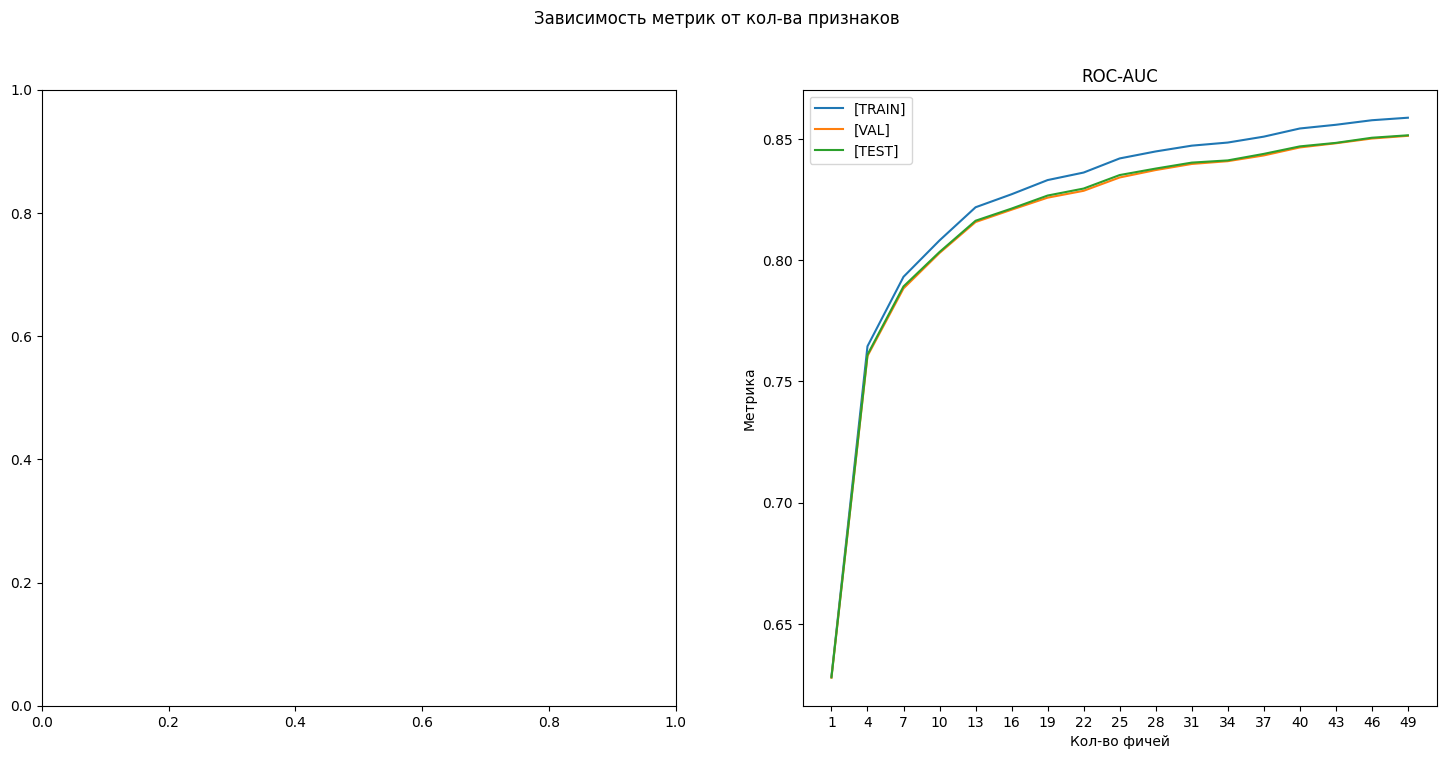

In [78]:
fig, axs = plt.subplots(ncols = 2, figsize = (18, 8), )

fig.suptitle('Зависимость метрик от кол-ва признаков')


plt.title('Метрики от кол-ва фичей')
plt.ylabel('Метрика')
plt.xlabel('Кол-во фичей')


# axs[0].plot(train_f1, label = '[TRAIN]')
# axs[0].plot(val_f1, label = '[VAL]')
# axs[0].plot(test_f1, label = '[TEST]')

# axs[0].set_title('F1')
# axs[0].set_xticks(ticks = list(range(len(train_f1))), labels = xticks)
# axs[0].set_xlabel('Кол-во фичей')
# axs[0].set_ylabel('Метрика')




axs[1].plot(train_roc_auc, label = '[TRAIN]')
axs[1].plot(val_roc_auc, label = '[VAL]')
axs[1].plot(test_roc_auc, label = '[TEST]')

axs[1].set_title('ROC-AUC')
axs[1].set_xlabel('Кол-во фичей')
axs[1].set_ylabel('Метрика')

axs[1].set_xticks(ticks = list(range(len(train_roc_auc))), labels = xticks)


axs[1].legend();

In [79]:
num_features = 25
final_features = importances[:num_features]

In [80]:
final_features

['dep_acct_dep_td_bal_rub_amt_12m',
 'dep_inf_new_acct_rub_amt_sum_12m',
 'seg_crm_day_qty',
 'dep_acct_dep_save_bal_rub_amt_sum_12m',
 'dep_acct_dep_save_bal_rub_amt',
 'tot_bal_with_invest_12m',
 'dep_acct_dep_mnth_lst_open_qty',
 'tot_bal_with_invest_3m',
 'dep_acct_dep_tot_1000_qty',
 'seg_client_fl_segment_cd',
 'srv_sbol_txn_main_1m_amt_sum_12m',
 'dep_acct_dep_save_bal_rub_amt_sum_3m',
 'pfm_opened_cnt_all_12m',
 'dep_acct_dep_td_qty',
 'dep_inf_intr_cap_rub_amt',
 'seg_age_segment',
 'dep_acct_dc_bal_rub_amt_sum_12m',
 'srv_dc_p2p_otf_on_amt_sum_12m',
 'crd_otf_trnf_pers_sbol_rub_amt_sum_12m',
 'pfm_started_cnt_all_12m',
 'srv_sbol_mob_1st_login_dt',
 'dep_acct_dep_mnth_lst_clsr_qty',
 'crd_otf_pos_spend_rub_amt_12m',
 'dep_acct_dep_td_bal_rub_amt_sum_3_6',
 'crd_cc_tot_otb_rub_amt']

In [81]:
final_features = ['dep_acct_dep_td_bal_rub_amt_12m',
 'dep_inf_new_acct_rub_amt_sum_12m',
 'seg_crm_day_qty',
 'dep_acct_dep_save_bal_rub_amt_sum_12m',
 'dep_acct_dep_save_bal_rub_amt',
 'tot_bal_with_invest_12m',
 'dep_acct_dep_mnth_lst_open_qty',
 'tot_bal_with_invest_3m',
 'dep_acct_dep_tot_1000_qty',
 'seg_client_fl_segment_cd',
 'srv_sbol_txn_main_1m_amt_sum_12m',
 'dep_acct_dep_save_bal_rub_amt_sum_3m',
 'pfm_opened_cnt_all_12m',
 'dep_acct_dep_td_qty',
 'dep_inf_intr_cap_rub_amt',
 'seg_age_segment',
 'dep_acct_dc_bal_rub_amt_sum_12m',
 'srv_dc_p2p_otf_on_amt_sum_12m',
 'crd_otf_trnf_pers_sbol_rub_amt_sum_12m',
 'pfm_started_cnt_all_12m',
 'srv_sbol_mob_1st_login_dt',
 'dep_acct_dep_mnth_lst_clsr_qty',
 'crd_otf_pos_spend_rub_amt_12m',
 'dep_acct_dep_td_bal_rub_amt_sum_3_6',
 'crd_cc_tot_otb_rub_amt']

## Last

In [82]:
x_train_last = x_train[final_features]
x_val_last = x_val[final_features]
x_test_last = x_test[final_features]

In [83]:
text_columns = x_train_last.select_dtypes(include=['object']).columns.tolist()

In [84]:
train_pool = Pool(x_train_last, y_train, cat_features=text_columns)
val_pool = Pool(x_val_last, y_val, cat_features=text_columns)
test_pool = Pool(x_test_last, y_test, cat_features=text_columns)

In [53]:
#text_columns_oot = train_df_oot.drop(columns='target').select_dtypes(include=['object']).columns.tolist()
#x = train_df_oot.drop(columns=['target', 'report_dt', 'epk_id'])
#y = train_df_oot['target']
#oot_pool = Pool(x, y, cat_features=text_columns_oot)

In [85]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', class_weights=class_weights,
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.5361250	test: 1.5360614	best: 1.5360614 (0)	total: 9.88ms	remaining: 9.88s
100:	learn: 1.1017310	test: 1.1060067	best: 1.1060067 (100)	total: 835ms	remaining: 7.44s
200:	learn: 1.0826835	test: 1.0898037	best: 1.0898037 (200)	total: 1.64s	remaining: 6.53s
300:	learn: 1.0737873	test: 1.0833869	best: 1.0833869 (300)	total: 2.45s	remaining: 5.68s
400:	learn: 1.0677834	test: 1.0798285	best: 1.0798285 (400)	total: 3.26s	remaining: 4.88s
500:	learn: 1.0630977	test: 1.0773651	best: 1.0773651 (500)	total: 4.08s	remaining: 4.06s
600:	learn: 1.0592509	test: 1.0755742	best: 1.0755742 (600)	total: 4.88s	remaining: 3.24s
700:	learn: 1.0559152	test: 1.0743681	best: 1.0743681 (700)	total: 5.7s	remaining: 2.43s
800:	learn: 1.0529597	test: 1.0733794	best: 1.0733789 (799)	total: 6.52s	remaining: 1.62s
900:	learn: 1.0502587	test: 1.0725227	best: 1.0725227 (900)	total: 7.33s	remaining: 805ms
999:	learn: 1.0478946	test: 1.0719455	best: 1.0719455 (999)	total: 8.14s	remaining: 0us
bestTest = 1.071

In [86]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")
#print(f"OOT : {roc_auc_score(y, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'macro')}")

TRAIN : 0.8394058692950789
VAL : 0.8313727124240383
TEST : 0.8323595903255847


In [87]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.61      0.31      0.41     30016
           2       0.56      0.62      0.59     29900
           3       0.62      0.47      0.53     23589
           4       0.41      0.69      0.51     30215
           5       0.62      0.55      0.58     29813

    accuracy                           0.53    143533
   macro avg       0.56      0.53      0.53    143533
weighted avg       0.56      0.53      0.52    143533



## Optuna

In [165]:
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int('n_estimators', 500, 2000),
        "learning_rate": trial.suggest_float('learning_rate', 0.01, 0.2),
        "depth": trial.suggest_int("depth", 3, 10),
        "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-2, 10),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 1.0),
        "min_child_samples": trial.suggest_float("min_child_samples", 100, 1000, step=100),
        "grow_policy": trial.suggest_categorical("grow_policy", ['SymmetricTree', 'Depthwise', 'Lossguide']),
        "border_count": trial.suggest_categorical("border_count", [128, 256, 512, 1024]),
        "auto_class_weights": trial.suggest_categorical("auto_class_weights", [None, 'Balanced', 'SqrtBalanced'])
    }
    
    acw = trial.suggest_categorical("auto_class_weights", [None, 'Balanced', 'SqrtBalanced'])
    if acw is not None:
        param['auto_class_weights'] = acw
    
    
    model = CatBoostClassifier(**param, verbose=False, loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass',  cat_features = text_columns)
        
    model.fit(train_pool, eval_set = val_pool, early_stopping_rounds=50, plot=False)
    
    val_roc_auc = roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'macro')
    
    train_roc_auc = roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'macro')
    
    if train_roc_auc - val_roc_auc > 0.03:
        return 0
    else:
        return val_roc_auc

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150)

In [30]:
# i can not show parameters, because i am under NDA
model = ctb.CatBoostClassifier(n_estimators=x, depth=x, learning_rate = x, l2_leaf_reg=x, 
                               colsample_bylevel=x, min_child_samples=x, grow_policy='x', border_count=x,
                               auto_class_weights='x',
                               verbose=x, loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=x, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.5700924	test: 1.5702911	best: 1.5702911 (0)	total: 525ms	remaining: 16m 28s
100:	learn: 1.1306107	test: 1.1371589	best: 1.1371589 (100)	total: 45.4s	remaining: 13m 20s
200:	learn: 1.1072609	test: 1.1195072	best: 1.1195072 (200)	total: 1m 28s	remaining: 12m 16s
300:	learn: 1.0937481	test: 1.1117168	best: 1.1117168 (300)	total: 2m 11s	remaining: 11m 29s
400:	learn: 1.0835843	test: 1.1075035	best: 1.1075035 (400)	total: 2m 55s	remaining: 10m 46s
500:	learn: 1.0753927	test: 1.1048539	best: 1.1048539 (500)	total: 3m 39s	remaining: 10m 6s
600:	learn: 1.0682970	test: 1.1031571	best: 1.1031571 (600)	total: 4m 22s	remaining: 9m 19s
700:	learn: 1.0617652	test: 1.1019524	best: 1.1019524 (700)	total: 5m 5s	remaining: 8m 34s
800:	learn: 1.0557316	test: 1.1011254	best: 1.1011254 (800)	total: 5m 47s	remaining: 7m 49s
900:	learn: 1.0502789	test: 1.1005183	best: 1.1005183 (900)	total: 6m 29s	remaining: 7m 4s
1000:	learn: 1.0449464	test: 1.0999598	best: 1.0999598 (1000)	total: 7m 13s	remaini

In [31]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'macro')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'macro')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'macro')}")
print(f"OOT : {roc_auc_score(y, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'macro')}")

TRAIN : 0.8646244621659662
VAL : 0.8391232918769853
TEST : 0.839566424043741
OOT : 0.7424664698229823


In [32]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'micro')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'micro')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'micro')}")
print(f"OOT : {roc_auc_score(y, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'micro')}")

TRAIN : 0.8676085073772493
VAL : 0.8433930680254794
TEST : 0.8438395839628492
OOT : 0.7665049324136359


In [33]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.55      0.43      0.48     30016
           2       0.62      0.55      0.58     29900
           3       0.59      0.52      0.55     23589
           4       0.47      0.55      0.51     30215
           5       0.56      0.70      0.62     29813

    accuracy                           0.55    143533
   macro avg       0.56      0.55      0.55    143533
weighted avg       0.56      0.55      0.55    143533



In [40]:
model.save_model('final_model_new_iter.cbm')